# Cross Account Lake Formation governed Feature Group Demo

This is a demo to showcase how cross account access would work with Lake Formation (LF) governed Feature Group (FG)

[simpler single account demo](./v3-feature-store-lake-formation.ipynb)  

The following scenario will be setup where you have a central account that owns the FG and then you have a producer account to ingest into the FG and another one reading from the FG

![image.png](./imgs/cross-account-feature-group-lakeformation-1.png)

## Helper Methods

In [ ]:
import boto3
import os

boto3.DEFAULT_SESSION = None
def assume_role(role_arn, session_name="AssumedRoleSession"):
    """
    Assume an AWS IAM role and return temporary credentials.
    
    Args:
        role_arn: The ARN of the role to assume
        session_name: A name for the assumed role session
    
    Returns:
        A boto3 session with the assumed role credentials
    """
    sts_client = boto3.client('sts')
    
    response = sts_client.assume_role(
        RoleArn=role_arn,
        RoleSessionName=session_name
    )
    
    credentials = response['Credentials']
    
    # Create a new session with the temporary credentials
    session = boto3.Session(
        aws_access_key_id=credentials['AccessKeyId'],
        aws_secret_access_key=credentials['SecretAccessKey'],
        aws_session_token=credentials['SessionToken']
    )
    
    return session

### Setup

In [ ]:
import json
import boto3
from botocore.exceptions import ClientError
# Import the FeatureGroup with Lake Formation support
from sagemaker.mlops.feature_store import FeatureGroupManager, LakeFormationConfig
from sagemaker.core.shapes import (
    FeatureDefinition,
    OfflineStoreConfig,
    OnlineStoreConfig,
    S3StorageConfig,
)
from sagemaker.core.helper.session_helper import Session as SageMakerSession

initialize a sagemaker session for for each account (central, producer, consumer)

In [ ]:
central_account  = "<account-id>"
producer_account = "<account-id>"
consumer_account = "<account-id>"

acc_to_role_arn = {
    central_account: f"arn:aws:iam::{central_account}:role/<role>",
    producer_account: f"arn:aws:iam::{producer_account}:role/<role>",
    consumer_account: f"arn:aws:iam::{consumer_account}:role/<role>"
}
central_acc_boto_session = assume_role(acc_to_role_arn[central_account])
central_acc_sagemaker_session = SageMakerSession(boto_session=central_acc_boto_session)

producer_acc_boto_session = assume_role(acc_to_role_arn[producer_account])
producer_acc_sagemaker_session = SageMakerSession(boto_session=producer_acc_boto_session)

consumer_acc_boto_session = assume_role(acc_to_role_arn[consumer_account])
consumer_acc_sagemaker_session = SageMakerSession(boto_session=consumer_acc_boto_session)


Initialize clients for Lake Formation, glue, and ram

In [ ]:
# lakeformation
central_lf_client = central_acc_boto_session.client('lakeformation')
consumer_lf_client = consumer_acc_boto_session.client('lakeformation')

# glue
central_glue_client = central_acc_boto_session.client('glue')
consumer_glue_client = consumer_acc_boto_session.client('glue')
producer_glue_client = producer_acc_boto_session.client('glue')

# RAM
central_ram_client = central_acc_boto_session.client("ram")
producer_ram_client = producer_acc_boto_session.client("ram")
consumer_ram_client = consumer_acc_boto_session.client("ram")

## 1. Create Feature Group in central account and register it with Lake Formation

We will create a Feature Group with online and offline store. We will use the execution role as a registration role for Lake Formation for simplicity. 
The registration role is the role Lake Formation uses to access your s3 bucket. You also have the option to use a service linked role (SLR). **However, an SLR cannot be used with cross-account credential vending.**

**Hybrid access mode must also be disabled on Glue Table and Database in order for cross-account credential vending to work**

![lakeformation flow](./imgs/lakeformation-flow.png)

In [ ]:
FEATURE_GROUP_NAME='lakeformation-managed-fg'

In [ ]:
feature_definitions = [
    FeatureDefinition(feature_name="customer_id", feature_type="String"),
    FeatureDefinition(feature_name="event_time", feature_type="String"),
    FeatureDefinition(feature_name="age", feature_type="Integral"),
    FeatureDefinition(feature_name="total_purchases", feature_type="Integral"),
    FeatureDefinition(feature_name="avg_order_value", feature_type="Fractional"),
]

# Offline store execution role (dedicated role for Feature Store S3 access) 
# https://docs.aws.amazon.com/sagemaker/latest/dg/feature-store-adding-policies.html
# Using the same role as the demo execution role but it doesn't need to be the same
OFFLINE_STORE_ROLE_ARN = acc_to_role_arn[central_account]

S3_BUCKET = central_acc_sagemaker_session.default_bucket()
REGION = central_acc_boto_session.region_name

# Configure online and offline stores
online_store_config = OnlineStoreConfig(enable_online_store=True)

offline_store_config = OfflineStoreConfig(
    s3_storage_config=S3StorageConfig(
        s3_uri=f"s3://{S3_BUCKET}/feature-store-demo/"
    ),
    table_format='Iceberg'
)

# Configure Lake Formation - enabled at creation
lake_formation_config = LakeFormationConfig(
    enabled=True,
    use_service_linked_role=False,
    registration_role_arn=acc_to_role_arn[central_account],
    hybrid_access_mode_enabled=False,
    acknowledge_risk=True # You acknowledge that IAM based access to the glue table will stop working
)

# create FG in central account and enable LF
feature_group = FeatureGroupManager.create(
    feature_group_name=FEATURE_GROUP_NAME,
    record_identifier_feature_name="customer_id",
    event_time_feature_name="event_time",
    feature_definitions=feature_definitions,
    online_store_config=online_store_config,
    offline_store_config=offline_store_config,
    role_arn=OFFLINE_STORE_ROLE_ARN,
    description="Feature Group with Lake Formation enabled",
    lake_formation_config=lake_formation_config, # new parameter
    session=central_acc_boto_session,
    region=REGION
)

print(f"\nFeature Group created: {feature_group.feature_group_name}")

In [ ]:
feature_group = FeatureGroupManager.get(FEATURE_GROUP_NAME)

In [ ]:
feature_group.refresh()
feature_group_arn = feature_group.feature_group_arn
data_catalog_config = feature_group.offline_store_config.data_catalog_config
database_name = str(data_catalog_config.database)
table_name = str(data_catalog_config.table_name)
catalog_id = str(data_catalog_config.catalog)
print(feature_group_arn)

## 2. Share Feature Group with producer account

We have 2 options to share a feature group
1. use RAM sharing to allow producer to call sagemaker:putRecord on feature group in central account (doesn't require Lake Formation)
2. use Lake Formation to share offline store with producer and the producer ingests directly to offline store

### 2.a RAM sharing

- central account shares feature group with producer account
- producer account access the RAM share and does data plane operations like putRecord and getRecord

In [ ]:
response = central_ram_client.create_resource_share(
    name='producer-account-fg-share',
    resourceArns=[
        feature_group_arn
    ],
    principals=[
        str(producer_account)
    ],
    permissionArns=[
        "arn:aws:ram::aws:permission/AWSRAMPermissionSageMakerFeatureGroupReadWrite"
    ]
)
response

In [ ]:
# Producer account accepts the RAM invitation
response = producer_ram_client.get_resource_share_invitations()
pending = [
    inv for inv in response['resourceShareInvitations']
    if inv['status'] == 'PENDING' and inv['senderAccountId'] == str(central_account)
]

for inv in pending:
    producer_ram_client.accept_resource_share_invitation(
        resourceShareInvitationArn=inv['resourceShareInvitationArn']
    )
    print(f"Accepted: {inv['resourceShareInvitationArn']}")


#### Ingesting using Sagemaker API

In [ ]:
from datetime import datetime, timezone

# Use the producer session to call PutRecord on the shared Feature Group
sm_runtime = producer_acc_boto_session.client('sagemaker-featurestore-runtime')

sm_runtime.put_record(
    FeatureGroupName=feature_group_arn,
    Record=[
        {'FeatureName': 'customer_id', 'ValueAsString': 'CUST-001'},
        {'FeatureName': 'event_time', 'ValueAsString': datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%S') + 'Z'},
        {'FeatureName': 'age', 'ValueAsString': '35'},
        {'FeatureName': 'total_purchases', 'ValueAsString': '12'},
        {'FeatureName': 'avg_order_value', 'ValueAsString': '49.99'},
    ]
)

Retrieve record from online store and record will also be replicated to offline store later

In [ ]:
# Test getRecord
sm_runtime.get_record(
    FeatureGroupName=feature_group_arn,
    RecordIdentifierValueAsString='CUST-001'
)

#### 2.b Using direct ingestion to Glue table via LF credential vending + PyIceberg

In [ ]:
# Setup credential vending for cross-account PyIceberg writes
import time

PRODUCER_RL_DB = 'sagemaker_featurestore_rl'

# Enable credential vending in data lake settings
try:
    settings = central_lf_client.get_data_lake_settings()['DataLakeSettings']
    settings['AllowFullTableExternalDataAccess'] = True
    settings['CreateDatabaseDefaultPermissions'] = []
    settings['CreateTableDefaultPermissions'] = []
    central_lf_client.put_data_lake_settings(DataLakeSettings=settings)
    print('Data lake settings updated: AllowFullTableExternalDataAccess=True')
except ClientError as e:
    print(f'put_data_lake_settings: {e}')

# Revoke IAMAllowedPrincipals from database
try:
    central_lf_client.revoke_permissions(
        Principal={'DataLakePrincipalIdentifier': 'IAM_ALLOWED_PRINCIPALS'},
        Resource={'Database': {'CatalogId': central_account, 'Name': database_name}},
        Permissions=['ALL'],
    )
    print(f'Revoked IAMAllowedPrincipals from database {database_name}')
except ClientError as e:
    if 'InvalidInputException' in str(e):
        print(f'Already revoked from database {database_name}')
    else:
        print(f'Revoke error: {e}')


# Grant table permissions (ALL) to producer account. Needed for write access to underlying s3 path
try:
    central_lf_client.grant_permissions(
        Principal={'DataLakePrincipalIdentifier': acc_to_role_arn[producer_account]},
        Resource={'Table': {'CatalogId': str(central_account), 'DatabaseName': database_name, 'Name': table_name}},
        Permissions=['ALL'],
        PermissionsWithGrantOption=[],
    )
    print('Granted ALL on table')
except ClientError as e:
    print(f'Table grant: {e}')

# Grant DATABASE DESCRIBE to producer
try:
    central_lf_client.grant_permissions(
        Principal={'DataLakePrincipalIdentifier': acc_to_role_arn[producer_account]},
        Resource={'Database': {'CatalogId': str(central_account), 'Name': database_name}},
        Permissions=['DESCRIBE'],
    )
    print('Granted DESCRIBE on database')
except ClientError as e:
    print(f'Database grant: {e}')

# Grant DATA_LOCATION_ACCESS on registered S3 path for credential vending
glue_resp = central_glue_client.get_table(DatabaseName=database_name, Name=table_name)
table_location = glue_resp['Table']['StorageDescriptor']['Location']
registered_s3_arn = table_location.replace('s3://', 'arn:aws:s3:::')
try:
    central_lf_client.grant_permissions(
        Principal={'DataLakePrincipalIdentifier': acc_to_role_arn[producer_account]},
        Resource={'DataLocation': {'CatalogId': str(central_account), 'ResourceArn': registered_s3_arn}},
        Permissions=['DATA_LOCATION_ACCESS'],
        PermissionsWithGrantOption=[],
    )
    print('Granted DATA_LOCATION_ACCESS')
except ClientError as e:
    print(f'DATA_LOCATION_ACCESS grant: {e}')


In [ ]:
# Create Glue resource link in producer account pointing to glue table in central account
try:
    producer_glue_client.create_database(DatabaseInput={'Name': PRODUCER_RL_DB})
    print(f'Created database: {PRODUCER_RL_DB}')
except producer_glue_client.exceptions.AlreadyExistsException:
    print(f'Database already exists: {PRODUCER_RL_DB}')
try:
    producer_glue_client.create_table(
        DatabaseName=PRODUCER_RL_DB,
        TableInput={'Name': table_name, 'TargetTable': {'CatalogId': str(central_account), 'DatabaseName': database_name, 'Name': table_name}},
    )
    print(f'Created resource link: {PRODUCER_RL_DB}.{table_name}')
except producer_glue_client.exceptions.AlreadyExistsException:
    print(f'Resource link already exists: {PRODUCER_RL_DB}.{table_name}')

# Accept the auto-created RAM share from LF grant_permissions
print('Waiting 15s for LF-created RAM invitation to propagate...')
time.sleep(15)
response = producer_ram_client.get_resource_share_invitations()
pending = [inv for inv in response['resourceShareInvitations'] if inv['status'] == 'PENDING' and inv['senderAccountId'] == str(central_account)]
for inv in pending:
    producer_ram_client.accept_resource_share_invitation(resourceShareInvitationArn=inv['resourceShareInvitationArn'])
    print(f'Accepted RAM invitation: {inv["resourceShareInvitationArn"]}')
if not pending:
    print('No pending RAM invitations (may already be accepted)')

**Hybrid access mode must be disabled on Glue Table and Database in order for cross-account credential vending to work**

In [ ]:
# Producer inserts data via PyIceberg using LF credential vending
import pyarrow as pa
from pyiceberg.catalog import load_catalog
from datetime import datetime, timezone

region = producer_acc_boto_session.region_name

# Resolve resource link to target table
resp = producer_glue_client.get_table(DatabaseName=PRODUCER_RL_DB, Name=table_name)
target = resp['Table'].get('TargetTable')
if not target:
    raise RuntimeError('Could not resolve resource link')
target_catalog_id = target['CatalogId']
target_db = target['DatabaseName']
target_table = target['Name']
print(f'Resolved -> catalog={target_catalog_id}, db={target_db}, table={target_table}')

# Get temporary credentials from Lake Formation
lf_client = producer_acc_boto_session.client('lakeformation', region_name=region)
cred_response = lf_client.get_temporary_glue_table_credentials(
    TableArn=f'arn:aws:glue:{region}:{target_catalog_id}:table/{target_db}/{target_table}',
    Permissions=['SELECT', 'INSERT', 'DESCRIBE'],
)
access_key = cred_response['AccessKeyId']
secret_key = cred_response['SecretAccessKey']
session_token = cred_response['SessionToken']
print('Obtained Lake Formation temporary credentials')

# Load PyIceberg catalog (producer creds for Glue, LF creds for S3)
producer_creds = producer_acc_boto_session.get_credentials().get_frozen_credentials()
catalog = load_catalog(
    'glue',
    **{
        'type': 'glue',
        'glue.region': region,
        'glue.access-key-id': producer_creds.access_key,
        'glue.secret-access-key': producer_creds.secret_key,
        'glue.session-token': producer_creds.token,
        's3.region': region,
        's3.access-key-id': access_key,
        's3.secret-access-key': secret_key,
        's3.session-token': session_token,
    },
)
iceberg_table = catalog.load_table(f'{PRODUCER_RL_DB}.{table_name}')
print(f'Loaded Iceberg table: {target_db}.{target_table}')

now = datetime.now(timezone.utc)
data = pa.table({
    'customer_id': ['CUST-002-lf-creds'],
    'event_time': ['2025-01-15T12:00:00Z'],
    'age': pa.array([30], type=pa.int64()),
    'total_purchases': pa.array([50], type=pa.int64()),
    'avg_order_value': pa.array([99.99], type=pa.float64()),
    'write_time': pa.array([now], type=pa.timestamp('us', tz='UTC')),
    'api_invocation_time': pa.array([now], type=pa.timestamp('us', tz='UTC')),
    'is_deleted': [False],
})
iceberg_table.append(data)
print(f'Successfully appended {len(data)} record(s) via PyIceberg')

## 3. Share Glue Table with consumer account

### Allow consumer account access to DB in central account

For cross account glue table access we have 2 options to share a glue table 
1. Add a glue resource policy granting the consumer account permission
2. Create an IAM role in producer account that consumer can assume

ref: https://docs.aws.amazon.com/glue/latest/dg/cross-account-access.html

For this demo we will use option 1 for simplicity

In [ ]:

# See: https://docs.aws.amazon.com/glue/latest/dg/cross-account-access.html
import json
print("Setting Glue resource policy for cross-account access...")

# Glue normalizes database names to lowercase in ARNs
db_name_lower = database_name.lower()
region = central_acc_boto_session.region_name
try:
    current = central_glue_client.get_resource_policy()
    print(f"Current Glue resource policy:\n{json.dumps(json.loads(current['PolicyInJson']), indent=2)}")
    policy_hash = current.get("PolicyHash")
except central_glue_client.exceptions.EntityNotFoundException:
    print("No existing Glue resource policy")
    policy_hash = None

new_statement = {
    "Sid": "AllowConsumerGlueAccess",
    "Effect": "Allow",
    "Principal": {"AWS": f"arn:aws:iam::{consumer_account}:root"},
    "Action": "glue:*",
    "Resource": [
        f"arn:aws:glue:{region}:{central_account}:catalog",
        f"arn:aws:glue:{region}:{central_account}:database/{db_name_lower}",
        f"arn:aws:glue:{region}:{central_account}:table/{db_name_lower}/*",
    ],
}

if policy_hash:
    existing = json.loads(central_glue_client.get_resource_policy()["PolicyInJson"])
    stmts = [s for s in existing.get("Statement", []) if s.get("Sid") != "AllowConsumerGlueAccess"]
    stmts.append(new_statement)
    glue_policy = {"Version": "2012-10-17", "Statement": stmts}
else:
    glue_policy = {"Version": "2012-10-17", "Statement": [new_statement]}

try:
    kwargs = {"PolicyInJson": json.dumps(glue_policy), "EnableHybrid": "TRUE"}
    if policy_hash:
        kwargs["PolicyHashCondition"] = policy_hash
    central_glue_client.put_resource_policy(**kwargs)
    print(f"Glue resource policy updated (using lowercase db: {db_name_lower})")
except ClientError as e:
    print(f"Error setting Glue resource policy: {e}")


### Share the glue table with consumer by using an LF tag

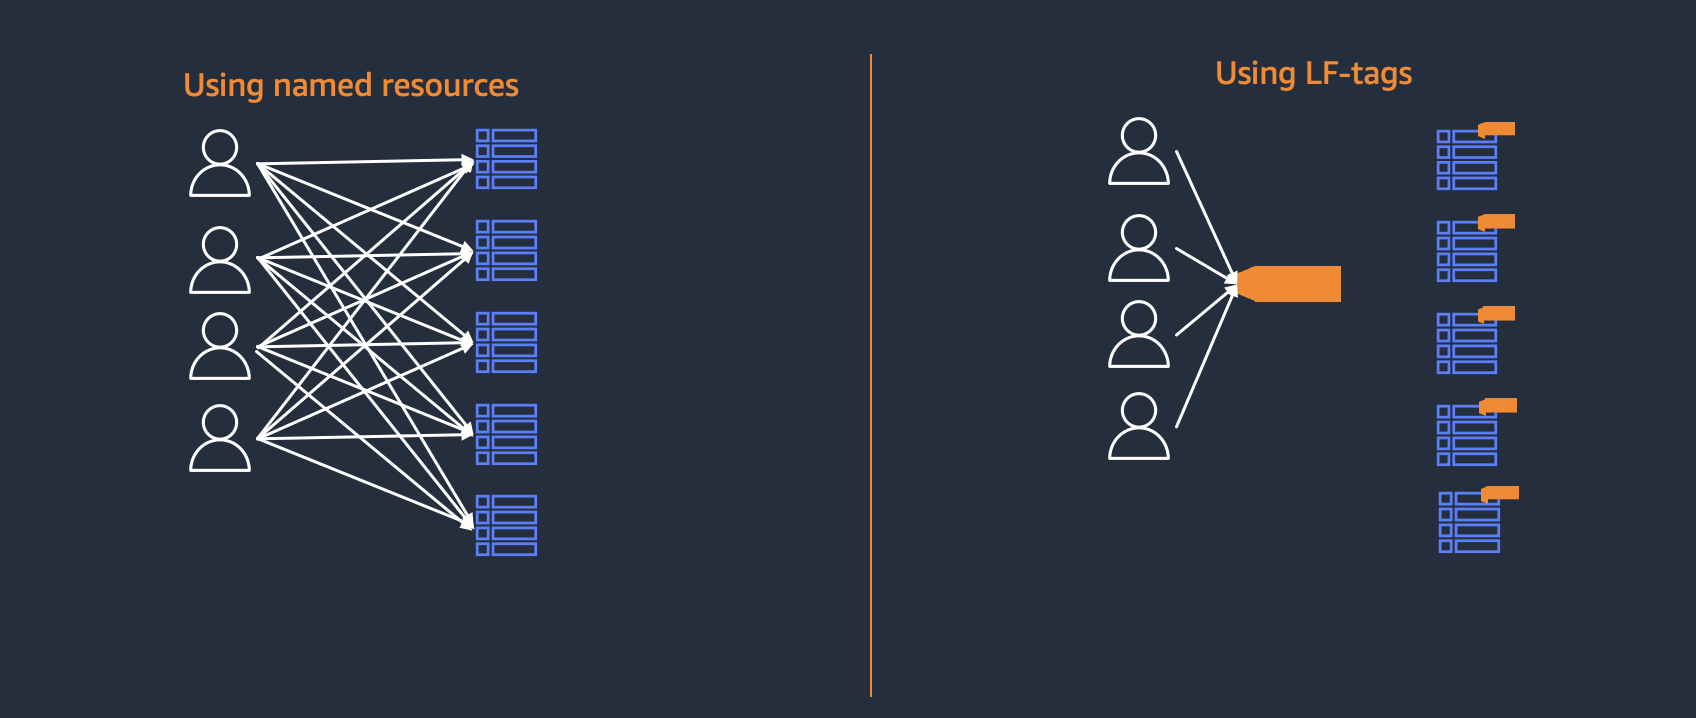

In [ ]:
try:
    central_lf_client.revoke_permissions(
        Principal={"DataLakePrincipalIdentifier": "IAM_ALLOWED_PRINCIPALS"},
        Resource={"Database": {"CatalogId": central_account, "Name": database_name}},
        Permissions=["ALL"],
    )
    print(f"Revoked IAMAllowedPrincipals from central DB: {database_name}")
except ClientError as e:
    if "InvalidInput" in str(e):
        print(f"IAMAllowedPrincipals already revoked from central DB: {database_name}")
    else:
        print(f"Error revoking from central DB: {e}")

### Add LF tag to glue table

The central account has an LF tag  `data_classification:dev` which we will first add to glue table and grant consumer role permissions to that tag

This is only one way to share permissions you can also grant direct permissions instead of using lf tags

In [ ]:
central_lf_client.get_data_lake_settings()

central_lf_client.add_lf_tags_to_resource(
    Resource={
        'Table': {
            'CatalogId': str(central_account),
            'DatabaseName': database_name,
            'Name': table_name
        }
    },
    LFTags=[
        {
            'CatalogId': str(central_account),
            'TagKey': 'data_classification',
            'TagValues': ['dev']
        }
    ]
)
print(f"Tagged table {database_name}.{table_name} with data_classification=dev")


Now we need to grant the role in consumer account permissions to the LF tag

In [ ]:
central_lf_client.grant_permissions(
    Principal={
        'DataLakePrincipalIdentifier': acc_to_role_arn[consumer_account]
    },
    Resource={
        'LFTagPolicy': {
            'CatalogId': str(central_account),
            'ResourceType': 'TABLE',
            'Expression': [
                {
                    'TagKey': 'data_classification',
                    'TagValues': ['dev']
                }
            ]
        }
    },
    Permissions=['SELECT', 'DESCRIBE'],
    PermissionsWithGrantOption=[]
)

print(f"Granted LF-tag based SELECT/DESCRIBE to consumer account {consumer_account}")


# For Iceberg tables, consumer also needs DATA_LOCATION_ACCESS for credential vending
s3_uri = feature_group.offline_store_config.s3_storage_config.resolved_output_s3_uri
s3_arn =  "arn:aws:s3:::" + s3_uri.replace("s3://", "").rsplit("/data", 1)[0]

try:
    central_lf_client.grant_permissions(
        Principal={'DataLakePrincipalIdentifier': acc_to_role_arn[consumer_account]},
        Resource={'DataLocation': {'CatalogId': str(central_account), 'ResourceArn': s3_arn}},
        Permissions=['DATA_LOCATION_ACCESS'],
        PermissionsWithGrantOption=[],
    )
    print(f'Granted DATA_LOCATION_ACCESS on {s3_arn} to consumer')
except ClientError as e:
    print(f'DATA_LOCATION_ACCESS grant: {e}')


Cross account Lake Formation grant permissions automatically creates a RAM share so we need to accept that in consumer account

In [ ]:
# Consumer account accepts the RAM invitation

response = consumer_ram_client.get_resource_share_invitations()
pending = [
    inv for inv in response['resourceShareInvitations']
    if inv['status'] == 'PENDING' and inv['senderAccountId'] == str(central_account)
]
for inv in pending:
    consumer_ram_client.accept_resource_share_invitation(
        resourceShareInvitationArn=inv['resourceShareInvitationArn']
    )
    print(f"Accepted: {inv['resourceShareInvitationArn']}")

## 4. Consumer reads data from the glue table using Athena

create a link between glue table in central and the consumer account

In [ ]:
CONSUMER_DB_NAME = 'shared_feature_store_db'
consumer_role_arn = acc_to_role_arn[consumer_account]

try:
    consumer_glue_client.create_database(
        DatabaseInput={'Name': CONSUMER_DB_NAME}
    )
    print(f"Created database: {CONSUMER_DB_NAME}")
except consumer_glue_client.exceptions.AlreadyExistsException:
    print(f"Database {CONSUMER_DB_NAME} already exists")

# Revoke IAMAllowedPrincipals from consumer database
try:
    consumer_lf_client.revoke_permissions(
        Principal={'DataLakePrincipalIdentifier': 'IAM_ALLOWED_PRINCIPALS'},
        Resource={'Database': {'CatalogId': consumer_account, 'Name': CONSUMER_DB_NAME}},
        Permissions=['ALL'],
    )
    print(f'Revoked IAMAllowedPrincipals from {CONSUMER_DB_NAME}')
except ClientError as e:
    if 'InvalidInput' in str(e):
        print(f'IAMAllowedPrincipals already revoked from {CONSUMER_DB_NAME}')
    else:
        print(f'Revoke error: {e}')

# Create resource link
link_name = f'{table_name}_link'
try:
    consumer_glue_client.create_table(
        DatabaseName=CONSUMER_DB_NAME,
        TableInput={
            'Name': link_name,
            'TargetTable': {
                'CatalogId': str(central_account),
                'DatabaseName': database_name,
                'Name': table_name
            }
        }
    )
    print(f"Created resource link: {CONSUMER_DB_NAME}.{link_name}")
except consumer_glue_client.exceptions.AlreadyExistsException:
    print("Resource link already exists")

# Grant DESCRIBE on resource link to consumer role
try:
    consumer_lf_client.grant_permissions(
        Principal={'DataLakePrincipalIdentifier': consumer_role_arn},
        Resource={
            'Table': {
                'CatalogId': consumer_account,
                'DatabaseName': CONSUMER_DB_NAME,
                'Name': link_name,
            }
        },
        Permissions=['DESCRIBE'],
    )
    print(f'Granted DESCRIBE on resource link to {consumer_role_arn}')
except ClientError as e:
    if 'InvalidInput' in str(e) and 'already' in str(e).lower():
        print('DESCRIBE on resource link already granted')
    else:
        print(f'Error: {e}')


In [ ]:
# For Iceberg tables, the consumer account's data lake settings must enable
# AllowFullTableExternalDataAccess so that Athena uses LF credential vending
# to read S3 data. The ___use_lakeformation_credentials___ flag on the resource
# link is determined by the resource link owner account's settings.
settings = consumer_lf_client.get_data_lake_settings()['DataLakeSettings']
settings['AllowFullTableExternalDataAccess'] = True
settings['CreateDatabaseDefaultPermissions'] = []
settings['CreateTableDefaultPermissions'] = []
consumer_lf_client.put_data_lake_settings(DataLakeSettings=settings)
print('Consumer data lake settings updated: AllowFullTableExternalDataAccess=True')


In [ ]:
import time

athena_client = consumer_acc_boto_session.client('athena')
CONSUMER_S3_BUCKET = consumer_acc_sagemaker_session.default_bucket()

# Query through the resource link in the consumer account
query = f'SELECT * FROM {CONSUMER_DB_NAME}.{table_name}_link LIMIT 10'

response = athena_client.start_query_execution(
    QueryString=query,
    ResultConfiguration={
        'OutputLocation': f's3://{CONSUMER_S3_BUCKET}/athena-results/'
    }
)

query_id = response['QueryExecutionId']
print(f"Query started: {query_id}")

while True:
    status = athena_client.get_query_execution(QueryExecutionId=query_id)
    state = status['QueryExecution']['Status']['State']
    if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
        break
    print(f"Status: {state}...")
    time.sleep(2)

if state == 'SUCCEEDED':
    results = athena_client.get_query_results(QueryExecutionId=query_id)
    for row in results['ResultSet']['Rows']:
        print([col.get('VarCharValue', '') for col in row['Data']])
else:
    reason = status['QueryExecution']['Status'].get('StateChangeReason', 'unknown')
    print(f"Query {state}: {reason}")


## 5. Cleanup


In [ ]:
# Delete resource links
consumer_glue_client.delete_table(DatabaseName=CONSUMER_DB_NAME, Name=f'{table_name}_link')
glue_producer = producer_acc_boto_session.client('glue')
glue_producer.delete_table(DatabaseName=PRODUCER_RL_DB, Name=table_name)

# Delete RAM shares
for share in central_ram_client.get_resource_shares(resourceOwner='SELF')['resourceShares']:
    if share['status'] == 'ACTIVE' and 'fg-share' in share.get('name', ''):
        central_ram_client.delete_resource_share(resourceShareArn=share['resourceShareArn'])

# Deregister S3 from Lake Formation
registered_arn = table_location.replace('s3://', 'arn:aws:s3:::')
central_lf_client.deregister_resource(ResourceArn=registered_arn)

# Remove consumer Glue resource policy statement
current = central_glue_client.get_resource_policy()
policy = json.loads(current['PolicyInJson'])
stmts = [s for s in policy['Statement'] if s.get('Sid') != 'AllowConsumerGlueAccess']
if stmts:
    central_glue_client.put_resource_policy(PolicyInJson=json.dumps({'Version': '2012-10-17', 'Statement': stmts}), PolicyHashCondition=current['PolicyHash'], EnableHybrid='TRUE')
else:
    central_glue_client.delete_resource_policy(PolicyHashCondition=current['PolicyHash'])

# Delete Feature Group
feature_group.delete()